# Portfolio Value at Risk (VaR) and Conditional Value at Risk (CVaR)

This project estimates portfolio downside risk using three approaches:

- Historical VaR / CVaR
- Parametric Normal VaR / CVaR
- Monte Carlo Normal VaR / CVaR

The portfolio consists of multiple asset classes, including equities, bonds, gold, foreign exchange, and crypto.

## Project Objective

The goal of this notebook is to measure the downside risk of a diversified portfolio using daily log returns.

We compare:
1. Historical estimation based on observed data
2. Parametric estimation under the assumption of normal returns
3. Monte Carlo simulation based on the estimated mean and volatility

This allows us to evaluate how different risk estimation methods behave on the same portfolio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## Data

We use daily prices from multiple asset classes (stocks, bonds, gold, FX, crypto).

In [2]:
tickers=["SPY","QQQ","TLT","GLD","EURUSD=X","BTC-USD"]
prices=yf.download(tickers,start="2016-01-01",auto_adjust=True)["Close"]

[*********************100%***********************]  6 of 6 completed


In [3]:
rets=np.log(prices/prices.shift(1))
rets=rets.dropna()
rets.tail()

Ticker,BTC-USD,EURUSD=X,GLD,QQQ,SPY,TLT
Date,,,,,,
2026-03-06,-0.038927,-0.002371,0.015708,-0.015158,-0.013194,-0.003724
2026-03-10,0.022043,0.008122,0.011217,0.000016,-0.001608,-0.010704
2026-03-11,0.003967,-0.000511,-0.003396,-0.000132,-0.001256,-0.012998
2026-03-12,0.004102,-0.005881,-0.019850,-0.017312,-0.015301,-0.001953
2026-03-13,0.006713,-0.001868,-0.013021,-0.005945,-0.005676,-0.004957


## Risk Estimation Methods

We compute:
- Historical VaR & CVaR
- Parametric (Normal) VaR & CVaR
- Monte Carlo VaR & CVaR

In [4]:
n=rets.shape[1]
w=np.ones(n)/n
port_rets=rets@w
loss=-port_rets
alpha=0.95
VaR_95=loss.quantile(alpha)
CVaR_95=loss[loss>=VaR_95].mean()

In [5]:
mu=port_rets.mean()
sigma=port_rets.std(ddof=1)
from scipy import stats
alpha=0.95
z=stats.norm.ppf(alpha)
VaR_norm_95=-(mu-z*sigma)

In [6]:
phi=stats.norm.pdf(z)
CVaR_norm_95=-(mu-sigma*(phi/(1-alpha)))

In [7]:
np.random.seed(42)
n_sim=100000
sim_rets=np.random.normal(mu,sigma,n_sim)
sim_loss=-sim_rets
alpha=0.95
VaR_mc_95=np.quantile(sim_loss,alpha)
CVaR_mc_95=sim_loss[sim_loss>=VaR_mc_95].mean()

In [8]:
print(f"Historical VaR 95%: {VaR_95:.6f} - Historical CVaR 95%: {CVaR_95:.6f}")
print(f"Normal VaR 95%:{VaR_norm_95:.6f} - Normal CVaR 95%: {CVaR_norm_95:.6f}")
print(f"Monte Carlo Normal VaR 95%: {VaR_mc_95:.6f} - Monte Carlo Normal CVaR 95%: {CVaR_mc_95:.6f}")

Historical VaR 95%: 0.013553 - Historical CVaR 95%: 0.020531
Normal VaR 95%:0.014323 - Normal CVaR 95%: 0.018087
Monte Carlo Normal VaR 95%: 0.014311 - Monte Carlo Normal CVaR 95%: 0.018106


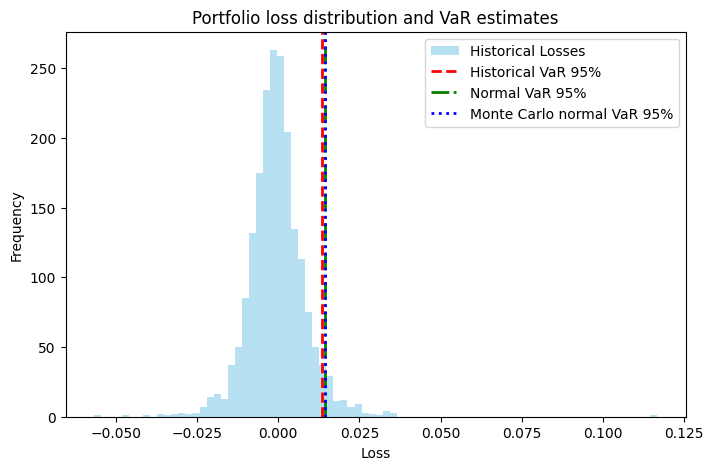

In [9]:
plt.figure(figsize=(8,5))
plt.hist(loss,bins=80,color="skyblue",alpha=0.6,label="Historical Losses")
plt.axvline(VaR_95,linewidth=2,color="red",linestyle="--",label="Historical VaR 95%")
plt.axvline(VaR_norm_95,linewidth=2,color="green",linestyle="-.",label="Normal VaR 95%")
plt.axvline(VaR_mc_95,linewidth=2,color="blue",linestyle=":",label="Monte Carlo normal VaR 95%")
plt.title("Portfolio loss distribution and VaR estimates")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Conclusion

The three approaches (Historical, Parametric Normal, and Monte Carlo) produce broadly similar VaR estimates, indicating that for this portfolio the normality assumption is not severely violated at the 95% confidence level.

However, the Historical CVaR is consistently higher than the Parametric estimate, suggesting the presence of heavier tails in the empirical return distribution. This implies that extreme losses occur more frequently than predicted by the normal model.

From a risk management perspective, this highlights an important limitation of parametric methods: while they are simple and computationally efficient, they may underestimate tail risk.

Overall, Historical and Monte Carlo approaches provide more robust estimates of downside risk, especially when dealing with non-normal financial returns.